# Entity Resolution and Golden Record Laboratory

## Notebook 01: Data Acquisition and Initial Audit

**Author:** Kazeem Wale Balogun  
**Project:** Building a Trusted Customer View  
**Purpose:** Load the FEBRL dataset, inspect its structure and conduct an initial data-quality assessment.


In [1]:
import sys

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)


Python executable:
c:\Users\DELL\venvs\entity-resolution-golden-record-lab\Scripts\python.exe

Python version:
3.13.14 (tags/v3.13.14:fd17997, Jun 10 2026, 13:03:48) [MSC v.1944 64 bit (AMD64)]


In [2]:
import pandas as pd
import numpy as np
import matplotlib
import sklearn
import recordlinkage
import ipykernel

print("All project libraries imported successfully.")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"Recordlinkage version: {recordlinkage.__version__}")
print(f"IPykernel version: {ipykernel.__version__}")

All project libraries imported successfully.
Pandas version: 2.3.3
NumPy version: 2.5.1
Scikit-learn version: 1.9.0
Recordlinkage version: 0.16
IPykernel version: 7.3.0


## 1. Data Acquisition

This project begins with FEBRL Dataset 1, a fictitious person-record dataset designed for testing record-linkage and duplicate-detection methods.

The dataset contains original records and deliberately corrupted duplicate records. The known matching pairs will be retained as the ground truth for evaluating the performance of rule-based and machine-learning approaches.

In [3]:
from recordlinkage.datasets import load_febrl1

print("FEBRL dataset loader imported successfully.")

FEBRL dataset loader imported successfully.


In [4]:
# Load FEBRL Dataset 1 and its known duplicate relationships
febrl_records, true_links = load_febrl1(return_links=True)

print("FEBRL Dataset 1 loaded successfully.")

FEBRL Dataset 1 loaded successfully.


In [5]:
print("Records object type:")
print(type(febrl_records))

print("\nTrue-links object type:")
print(type(true_links))

Records object type:
<class 'pandas.core.frame.DataFrame'>

True-links object type:
<class 'pandas.core.indexes.multi.MultiIndex'>


### 1.1 Dataset Dimensions

In [6]:
number_of_records, number_of_columns = febrl_records.shape
number_of_true_matches = len(true_links)

print(f"Number of records: {number_of_records:,}")
print(f"Number of columns: {number_of_columns}")
print(f"Number of known duplicate pairs: {number_of_true_matches:,}")

Number of records: 1,000
Number of columns: 10
Number of known duplicate pairs: 500


In [7]:
print("Dataset columns:")

for column_number, column_name in enumerate(
    febrl_records.columns,
    start=1
):
    print(f"{column_number}. {column_name}")

Dataset columns:
1. given_name
2. surname
3. street_number
4. address_1
5. address_2
6. suburb
7. postcode
8. state
9. date_of_birth
10. soc_sec_id


### 1.2 Initial Record Inspection

In [8]:
febrl_records.head()

,given_name,surname,street_number,address_1,address_2,suburb,postcode,state,date_of_birth,soc_sec_id
rec_id,,,,,,,,,,
rec-223-org,NaN,waller,6,tullaroop street,willaroo,st james,4011,wa,19081209,6988048
rec-122-org,lachlan,berry,69,giblin street,killarney,bittern,4814,qld,19990219,7364009
rec-373-org,deakin,sondergeld,48,goldfinch circuit,kooltuo,canterbury,2776,vic,19600210,2635962
rec-10-dup-0,kayla,harrington,NaN,maltby circuit,coaling,coolaroo,3465,nsw,19150612,9004242
rec-227-org,luke,purdon,23,ramsay place,mirani,garbutt,2260,vic,19831024,8099933


In [9]:
print("Index name:")
print(febrl_records.index.name)

print("\nFirst ten record identifiers:")
print(febrl_records.index[:10].tolist())

Index name:
rec_id

First ten record identifiers:
['rec-223-org', 'rec-122-org', 'rec-373-org', 'rec-10-dup-0', 'rec-227-org', 'rec-6-dup-0', 'rec-190-dup-0', 'rec-294-org', 'rec-206-dup-0', 'rec-344-org']


### 1.3 Known Duplicate Relationships

In [10]:
print("First ten known duplicate pairs:")

for record_id_1, record_id_2 in list(true_links[:10]):
    print(f"{record_id_1}  <->  {record_id_2}")

First ten known duplicate pairs:
rec-344-dup-0  <->  rec-344-org
rec-251-org  <->  rec-251-dup-0
rec-335-dup-0  <->  rec-335-org
rec-23-dup-0  <->  rec-23-org
rec-382-org  <->  rec-382-dup-0
rec-70-dup-0  <->  rec-70-org
rec-291-org  <->  rec-291-dup-0
rec-179-org  <->  rec-179-dup-0
rec-452-dup-0  <->  rec-452-org
rec-383-org  <->  rec-383-dup-0


In [11]:
# Select the first known duplicate pair
first_match_id, second_match_id = true_links[0]

print("First known duplicate pair:")
print(first_match_id, "<->", second_match_id)

febrl_records.loc[[first_match_id, second_match_id]]

First known duplicate pair:
rec-344-dup-0 <-> rec-344-org


,given_name,surname,street_number,address_1,address_2,suburb,postcode,state,date_of_birth,soc_sec_id
rec_id,,,,,,,,,,
rec-344-dup-0,NaN,stephenson,52,NaN,north stirilng downs,coolaroo,2259,qld,19630521,1797144
rec-344-org,NaN,julius,52,florey drive,north stirling downs,coolaroo,2259,qld,19630521,1797144


### Initial Observation

The selected record pair represents the same underlying person but contains differences across one or more identifying attributes. These variations illustrate why exact matching alone may fail to identify duplicate customer records.

Further analysis will determine which fields are complete, which types of variations occur most frequently and which attributes provide the strongest evidence for entity resolution.

## 2. Initial Data Quality Audit

The initial audit evaluates the structure, completeness, uniqueness and consistency of the FEBRL customer records before duplicate-detection rules or machine-learning models are developed.

Understanding the condition of the source data is essential because entity-resolution performance depends on the availability and reliability of the attributes used to compare records.

In [12]:
from pathlib import Path

current_working_directory = Path.cwd()

print("Current notebook working directory:")
print(current_working_directory)

Current notebook working directory:
c:\Users\DELL\OneDrive\Documents\GitHub\entity-resolution-golden-record-lab\notebooks


### 2.1 Dataset Structure

In [13]:
row_count, column_count = febrl_records.shape

print("FEBRL Dataset 1 structural overview")
print("-----------------------------------")
print(f"Number of records: {row_count:,}")
print(f"Number of columns: {column_count}")
print(f"Number of known duplicate pairs: {len(true_links):,}")
print(f"Index name: {febrl_records.index.name}")
print(f"Are record identifiers unique? {febrl_records.index.is_unique}")

FEBRL Dataset 1 structural overview
-----------------------------------
Number of records: 1,000
Number of columns: 10
Number of known duplicate pairs: 500
Index name: rec_id
Are record identifiers unique? True


### 2.2 Field Completeness and Uniqueness

In [14]:
data_quality_summary = pd.DataFrame({
    "data_type": febrl_records.dtypes.astype(str),
    "non_null_count": febrl_records.notna().sum(),
    "missing_count": febrl_records.isna().sum(),
    "missing_percentage": (
        febrl_records.isna().mean() * 100
    ).round(2),
    "unique_value_count": febrl_records.nunique(dropna=True),
    "unique_percentage": (
        febrl_records.nunique(dropna=True)
        .div(len(febrl_records))
        .mul(100)
    ).round(2)
})

data_quality_summary = data_quality_summary.sort_values(
    by="missing_percentage",
    ascending=False
)

data_quality_summary

,data_type,non_null_count,missing_count,missing_percentage,unique_value_count,unique_percentage
address_2,object,885,115,11.5,585,58.5
street_number,object,955,45,4.5,154,15.4
given_name,object,956,44,4.4,378,37.8
date_of_birth,object,959,41,4.1,513,51.3
address_1,object,975,25,2.5,618,61.8
surname,object,982,18,1.8,494,49.4
suburb,object,982,18,1.8,520,52.0
state,object,985,15,1.5,17,1.7
postcode,object,1000,0,0.0,451,45.1
soc_sec_id,object,1000,0,0.0,550,55.0


### 2.3 Blank Strings and Whitespace

In [15]:
text_columns = febrl_records.select_dtypes(
    include=["object", "string"]
).columns.tolist()

blank_string_counts = {}
whitespace_issue_counts = {}

for column in text_columns:
    values = febrl_records[column].astype("string")

    blank_string_counts[column] = (
        values.str.strip()
        .eq("")
        .fillna(False)
        .sum()
    )

    whitespace_issue_counts[column] = (
        values.notna()
        & values.ne(values.str.strip())
    ).sum()

text_quality_summary = pd.DataFrame({
    "blank_string_count": pd.Series(blank_string_counts),
    "leading_or_trailing_space_count": pd.Series(
        whitespace_issue_counts
    )
})

text_quality_summary = text_quality_summary.sort_values(
    by=[
        "blank_string_count",
        "leading_or_trailing_space_count"
    ],
    ascending=False
)

text_quality_summary

,blank_string_count,leading_or_trailing_space_count
given_name,0,0
surname,0,0
street_number,0,0
address_1,0,0
address_2,0,0
suburb,0,0
postcode,0,0
state,0,0
date_of_birth,0,0
soc_sec_id,0,0


### 2.4 Exact Duplicate Records

In [16]:
exact_duplicate_records = febrl_records.duplicated().sum()

records_in_exact_duplicate_groups = (
    febrl_records.duplicated(keep=False).sum()
)

print(f"Exact duplicate records: {exact_duplicate_records:,}")
print(
    "Records belonging to exact duplicate groups: "
    f"{records_in_exact_duplicate_groups:,}"
)

Exact duplicate records: 0
Records belonging to exact duplicate groups: 0


**Interpretation:** Exact-row duplication does not capture the full entity-resolution problem. Records may refer to the same underlying person while containing spelling errors, missing attributes, transpositions or formatting differences. Approximate comparison methods are therefore required.

### 2.5 Field Completeness Visualisation

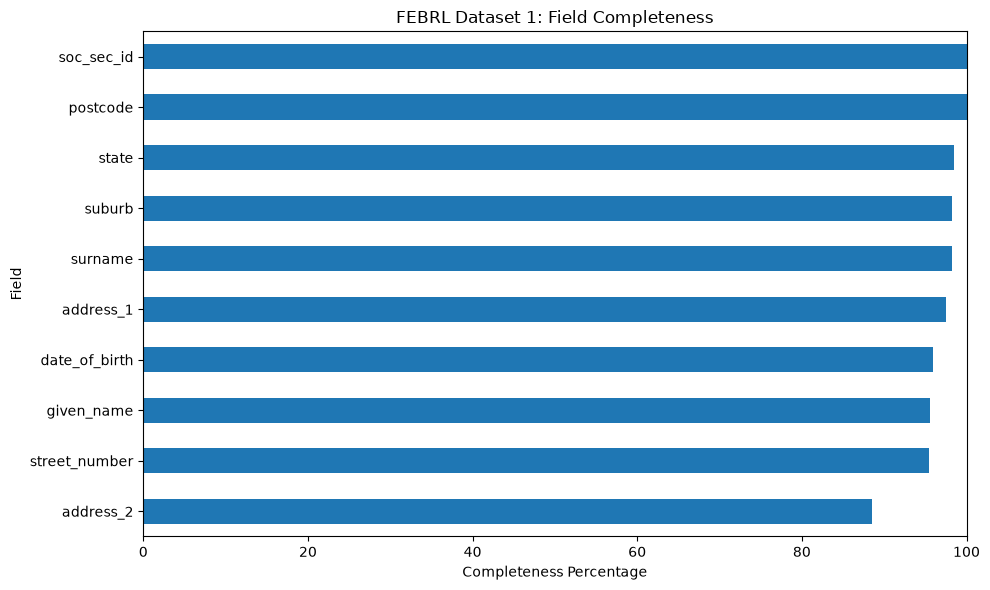

In [17]:
import matplotlib.pyplot as plt

field_completeness = (
    febrl_records.notna().mean()
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(10, 6))
field_completeness.plot(kind="barh")

plt.title("FEBRL Dataset 1: Field Completeness")
plt.xlabel("Completeness Percentage")
plt.ylabel("Field")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

### 2.6 Initial Audit Observations

The structural and completeness audit produced the following preliminary observations:

1. **Dataset size:** The dataset contains 1,000 records and 500 known duplicate relationships.

2. **Record identifiers:** The source record identifiers are unique and can therefore be used to track individual records and matching pairs.

3. **Most complete fields:** `soc_sec_id` and `postcode` are fully populated, with no missing values. `state`, `suburb`, and `surname` are also highly complete, with missingness of 1.8% or less.

4. **Least complete fields:** `address_2` has the highest level of missingness at 11.5%, followed by `street_number` at 4.5%, `given_name` at 4.4%, `date_of_birth` at 4.1%, and `address_1` at 2.5%.

5. **Exact duplicates:** No exact duplicate rows were identified. This confirms that the 500 known duplicate relationships contain variations or errors that prevent them from being detected through exact-row comparison.

6. **Formatting issues:** No blank strings or leading or trailing whitespace were detected. Missing values appear to be stored consistently as null values rather than as empty or space-filled strings.

7. **Uniqueness and matching value:** Completeness and uniqueness vary considerably across fields. Although `soc_sec_id` and `postcode` are complete, they contain 550 and 451 unique values respectively across 1,000 records. This indicates that no single field should automatically be treated as sufficient matching evidence.

8. **Entity-resolution implication:** The absence of exact duplicates, combined with missing and inconsistent identifying attributes, demonstrates the need to combine evidence across multiple fields. Approximate matching and carefully selected similarity measures will be required to identify records that refer to the same underlying person.

In [19]:
# Summarise the main findings from the initial data-quality audit

most_complete_fields = (
    data_quality_summary
    .sort_values(
        by=["missing_percentage", "unique_percentage"],
        ascending=[True, False]
    )
    .head(5)
)

least_complete_fields = (
    data_quality_summary
    .sort_values(
        by="missing_percentage",
        ascending=False
    )
    .head(5)
)

formatting_issues = text_quality_summary[
    (text_quality_summary["blank_string_count"] > 0)
    | (
        text_quality_summary[
            "leading_or_trailing_space_count"
        ] > 0
    )
]

exact_duplicate_records = febrl_records.duplicated().sum()

records_in_exact_duplicate_groups = (
    febrl_records.duplicated(keep=False).sum()
)

print("MOST COMPLETE FIELDS")
display(
    most_complete_fields[
        [
            "missing_count",
            "missing_percentage",
            "unique_value_count"
        ]
    ]
)

print("\nLEAST COMPLETE FIELDS")
display(
    least_complete_fields[
        [
            "missing_count",
            "missing_percentage",
            "unique_value_count"
        ]
    ]
)

print("\nFORMATTING ISSUES")
if formatting_issues.empty:
    print("No blank strings or surrounding whitespace detected.")
else:
    display(formatting_issues)

print("\nEXACT DUPLICATE RESULTS")
print(f"Exact duplicate records: {exact_duplicate_records:,}")
print(
    "Records belonging to exact duplicate groups: "
    f"{records_in_exact_duplicate_groups:,}"
)

MOST COMPLETE FIELDS


,missing_count,missing_percentage,unique_value_count
soc_sec_id,0,0.0,550
postcode,0,0.0,451
state,15,1.5,17
suburb,18,1.8,520
surname,18,1.8,494



LEAST COMPLETE FIELDS


,missing_count,missing_percentage,unique_value_count
address_2,115,11.5,585
street_number,45,4.5,154
given_name,44,4.4,378
date_of_birth,41,4.1,513
address_1,25,2.5,618



FORMATTING ISSUES
No blank strings or surrounding whitespace detected.

EXACT DUPLICATE RESULTS
Exact duplicate records: 0
Records belonging to exact duplicate groups: 0


## 3. Field-Level Validity and Standardisation Audit

This section examines whether individual fields follow consistent formats and plausible value patterns. The objective is to identify issues that may affect comparison, standardisation, feature engineering and duplicate-detection performance.

Validation rules will be developed only after the existing value patterns have been examined.

### 3.1 Value Patterns and Field Lengths

In [20]:
fields_for_pattern_review = [
    "given_name",
    "surname",
    "street_number",
    "address_1",
    "address_2",
    "suburb",
    "postcode",
    "state",
    "date_of_birth",
    "soc_sec_id"
]

field_pattern_summary = []

for column in fields_for_pattern_review:
    values = (
        febrl_records[column]
        .astype("string")
        .dropna()
        .str.strip()
    )

    value_lengths = values.str.len()

    field_pattern_summary.append({
        "field": column,
        "non_null_count": len(values),
        "minimum_length": int(value_lengths.min()),
        "median_length": float(value_lengths.median()),
        "maximum_length": int(value_lengths.max()),
        "unique_value_count": values.nunique()
    })

field_pattern_summary = pd.DataFrame(field_pattern_summary)

field_pattern_summary

,field,non_null_count,minimum_length,median_length,maximum_length,unique_value_count
0,given_name,956,3,6.0,15,378
1,surname,982,2,6.0,17,494
2,street_number,955,1,2.0,4,154
3,address_1,975,6,14.0,38,618
4,address_2,885,4,10.0,41,585
5,suburb,982,4,9.0,18,520
6,postcode,1000,4,4.0,4,451
7,state,985,2,3.0,3,17
8,date_of_birth,959,8,8.0,8,513
9,soc_sec_id,1000,7,7.0,7,550


In [21]:
for column in fields_for_pattern_review:
    sample_values = (
        febrl_records[column]
        .dropna()
        .astype("string")
        .drop_duplicates()
        .head(10)
        .tolist()
    )

    print(f"\n{column.upper()}")
    print("-" * len(column))

    for value in sample_values:
        print(value)


GIVEN_NAME
----------
lachlan
deakin
kayla
luke
darcie
william
abbey
isabella
anthony
alia

SURNAME
-------
waller
berry
sondergeld
harrington
purdon
trevorrow
turtur
bishop
lombardi
julius

STREET_NUMBER
-------------
6
69
48
23
16
10
21
36
52
13

ADDRESS_1
---------
tullaroop street
giblin street
goldfinch circuit
maltby circuit
ramsay place
dumas street
blacket street
neworra place
yerralee road
florey drive

ADDRESS_2
---------
willaroo
killarney
kooltuo
coaling
mirani
2/98-latchford barracks
eureka
apmnt 65
leisure living vlge
north stirling downs

SUBURB
------
st james
bittern
canterbury
coolaroo
garbutt
mount immaney
beverly hills
worongary
carlsruhe
yass

POSTCODE
--------
4011
4814
2776
3465
2260
2281
2263
6225
3149
2259

STATE
-----
wa
qld
vic
nsw
act
sa
vix
tas
nrw
nsq

DATE_OF_BIRTH
-------------
19081209
19990219
19600210
19150612
19831024
19530313
19490130
19870919
19630521
19870510

SOC_SEC_ID
----------
6988048
7364009
2635962
9004242
8099933
4811642
2025650
9773843
1

### Field-Pattern Observations

The field-length profile identifies three different structural patterns:

1. `postcode`, `date_of_birth`, and `soc_sec_id` have fixed lengths of 4, 8, and 7 characters respectively. These fields are suitable for pattern and format validation.

2. `state` contains values between two and three characters. This may reflect legitimate Australian state and territory abbreviations rather than a data-quality problem.

3. Names, addresses, and suburbs contain variable-length text values. Their length ranges appear plausible, but further inspection is required to identify punctuation, spelling variation, numeric contamination, and other inconsistencies.

4. `address_1` contains the highest number of distinct values among the reviewed fields, while `street_number` contains relatively few distinct values. Neither field should be used independently to identify a customer.

5. Field length alone cannot establish validity. Representative values and character patterns must be examined before formal validation rules are applied.

### 3.2 Representative Source Values

In [22]:
for column in fields_for_pattern_review:
    sample_values = (
        febrl_records[column]
        .dropna()
        .astype("string")
        .drop_duplicates()
        .head(10)
        .tolist()
    )

    print(f"\n{column.upper()}")
    print("-" * len(column))

    for value in sample_values:
        print(value)


GIVEN_NAME
----------
lachlan
deakin
kayla
luke
darcie
william
abbey
isabella
anthony
alia

SURNAME
-------
waller
berry
sondergeld
harrington
purdon
trevorrow
turtur
bishop
lombardi
julius

STREET_NUMBER
-------------
6
69
48
23
16
10
21
36
52
13

ADDRESS_1
---------
tullaroop street
giblin street
goldfinch circuit
maltby circuit
ramsay place
dumas street
blacket street
neworra place
yerralee road
florey drive

ADDRESS_2
---------
willaroo
killarney
kooltuo
coaling
mirani
2/98-latchford barracks
eureka
apmnt 65
leisure living vlge
north stirling downs

SUBURB
------
st james
bittern
canterbury
coolaroo
garbutt
mount immaney
beverly hills
worongary
carlsruhe
yass

POSTCODE
--------
4011
4814
2776
3465
2260
2281
2263
6225
3149
2259

STATE
-----
wa
qld
vic
nsw
act
sa
vix
tas
nrw
nsq

DATE_OF_BIRTH
-------------
19081209
19990219
19600210
19150612
19831024
19530313
19490130
19870919
19630521
19870510

SOC_SEC_ID
----------
6988048
7364009
2635962
9004242
8099933
4811642
2025650
9773843
1

In [23]:
state_values = sorted(
    febrl_records["state"]
    .dropna()
    .astype("string")
    .unique()
    .tolist()
)

print("Distinct state values:")
for value in state_values:
    print(repr(value))

Distinct state values:
'act'
'as'
'gas'
'msw'
'nrw'
'nsq'
'nsw'
'nt'
'qdl'
'qld'
'sa'
'tas'
'ua'
'vci'
'vic'
'vix'
'wa'


In [24]:
fixed_format_fields = [
    "postcode",
    "date_of_birth",
    "soc_sec_id"
]

for column in fixed_format_fields:
    print(f"\n{column.upper()} SAMPLE VALUES")
    print("-" * 30)

    sample_values = (
        febrl_records[column]
        .dropna()
        .astype("string")
        .drop_duplicates()
        .head(20)
        .tolist()
    )

    for value in sample_values:
        print(repr(value))


POSTCODE SAMPLE VALUES
------------------------------
'4011'
'4814'
'2776'
'3465'
'2260'
'2281'
'2263'
'6225'
'3149'
'2259'
'2594'
'4870'
'2477'
'6152'
'6210'
'2226'
'2794'
'2906'
'2528'
'3029'

DATE_OF_BIRTH SAMPLE VALUES
------------------------------
'19081209'
'19990219'
'19600210'
'19150612'
'19831024'
'19530313'
'19490130'
'19870919'
'19630521'
'19870510'
'19650714'
'19730924'
'19790418'
'19041118'
'19910424'
'19900909'
'19140707'
'19691123'
'19231209'
'19920711'

SOC_SEC_ID SAMPLE VALUES
------------------------------
'6988048'
'7364009'
'2635962'
'9004242'
'8099933'
'4811642'
'2025650'
'9773843'
'1613132'
'1797144'
'7661096'
'2790666'
'6558077'
'1975340'
'7994055'
'6426415'
'3877160'
'2534242'
'2624157'
'5107876'


### 3.3 Fixed-Format Field Validation

The sample values indicate that `postcode` should contain four numeric characters, `date_of_birth` should follow the `YYYYMMDD` format, and `soc_sec_id` should contain seven numeric characters.

The following tests evaluate format consistency across all non-missing values. These checks assess structural validity only. They do not confirm that a postcode is officially allocated or that an identifier represents a real person.

In [25]:
postcode_values = (
    febrl_records["postcode"]
    .astype("string")
    .str.strip()
)

postcode_valid_format = postcode_values.str.fullmatch(
    r"\d{4}",
    na=False
)

postcode_non_null = postcode_values.notna()

print("POSTCODE FORMAT VALIDATION")
print("--------------------------")
print(f"Non-null values: {postcode_non_null.sum():,}")
print(
    "Valid four-digit values: "
    f"{(postcode_valid_format & postcode_non_null).sum():,}"
)
print(
    "Invalid non-null values: "
    f"{(postcode_non_null & ~postcode_valid_format).sum():,}"
)

POSTCODE FORMAT VALIDATION
--------------------------
Non-null values: 1,000
Valid four-digit values: 1,000
Invalid non-null values: 0


In [26]:
date_of_birth_values = (
    febrl_records["date_of_birth"]
    .astype("string")
    .str.strip()
)

date_of_birth_non_null = date_of_birth_values.notna()

parsed_date_of_birth = pd.to_datetime(
    date_of_birth_values,
    format="%Y%m%d",
    errors="coerce"
)

date_of_birth_valid_format = parsed_date_of_birth.notna()

print("DATE OF BIRTH FORMAT VALIDATION")
print("--------------------------------")
print(f"Non-null values: {date_of_birth_non_null.sum():,}")
print(
    "Successfully parsed YYYYMMDD values: "
    f"{date_of_birth_valid_format.sum():,}"
)
print(
    "Invalid non-null values: "
    f"{(date_of_birth_non_null & ~date_of_birth_valid_format).sum():,}"
)

print("\nParsed date range:")
print(f"Earliest date: {parsed_date_of_birth.min()}")
print(f"Latest date: {parsed_date_of_birth.max()}")

DATE OF BIRTH FORMAT VALIDATION
--------------------------------
Non-null values: 959
Successfully parsed YYYYMMDD values: 956
Invalid non-null values: 3

Parsed date range:
Earliest date: 1900-04-04 00:00:00
Latest date: 1999-10-12 00:00:00


In [27]:
soc_sec_id_values = (
    febrl_records["soc_sec_id"]
    .astype("string")
    .str.strip()
)

soc_sec_id_valid_format = soc_sec_id_values.str.fullmatch(
    r"\d{7}",
    na=False
)

soc_sec_id_non_null = soc_sec_id_values.notna()

print("SYNTHETIC IDENTIFIER FORMAT VALIDATION")
print("--------------------------------------")
print(f"Non-null values: {soc_sec_id_non_null.sum():,}")
print(
    "Valid seven-digit values: "
    f"{(soc_sec_id_valid_format & soc_sec_id_non_null).sum():,}"
)
print(
    "Invalid non-null values: "
    f"{(soc_sec_id_non_null & ~soc_sec_id_valid_format).sum():,}"
)

SYNTHETIC IDENTIFIER FORMAT VALIDATION
--------------------------------------
Non-null values: 1,000
Valid seven-digit values: 1,000
Invalid non-null values: 0


In [28]:
fixed_format_validation_summary = pd.DataFrame({
    "field": [
        "postcode",
        "date_of_birth",
        "soc_sec_id"
    ],
    "expected_format": [
        "Exactly 4 numeric characters",
        "Valid date in YYYYMMDD format",
        "Exactly 7 numeric characters"
    ],
    "non_null_count": [
        int(postcode_non_null.sum()),
        int(date_of_birth_non_null.sum()),
        int(soc_sec_id_non_null.sum())
    ],
    "valid_count": [
        int((postcode_valid_format & postcode_non_null).sum()),
        int(date_of_birth_valid_format.sum()),
        int((soc_sec_id_valid_format & soc_sec_id_non_null).sum())
    ]
})

fixed_format_validation_summary["invalid_count"] = (
    fixed_format_validation_summary["non_null_count"]
    - fixed_format_validation_summary["valid_count"]
)

fixed_format_validation_summary["valid_percentage"] = (
    fixed_format_validation_summary["valid_count"]
    .div(fixed_format_validation_summary["non_null_count"])
    .mul(100)
    .round(2)
)

fixed_format_validation_summary

,field,expected_format,non_null_count,valid_count,invalid_count,valid_percentage
0,postcode,Exactly 4 numeric characters,1000,1000,0,100.00
1,date_of_birth,Valid date in YYYYMMDD format,959,956,3,99.69
2,soc_sec_id,Exactly 7 numeric characters,1000,1000,0,100.00


In [29]:
invalid_postcodes = febrl_records.loc[
    postcode_non_null & ~postcode_valid_format,
    "postcode"
]

invalid_dates_of_birth = febrl_records.loc[
    date_of_birth_non_null & ~date_of_birth_valid_format,
    "date_of_birth"
]

invalid_soc_sec_ids = febrl_records.loc[
    soc_sec_id_non_null & ~soc_sec_id_valid_format,
    "soc_sec_id"
]

print("INVALID POSTCODE VALUES")
print(invalid_postcodes.tolist())

print("\nINVALID DATE OF BIRTH VALUES")
print(invalid_dates_of_birth.tolist())

print("\nINVALID SYNTHETIC IDENTIFIER VALUES")
print(invalid_soc_sec_ids.tolist())

INVALID POSTCODE VALUES
[]

INVALID DATE OF BIRTH VALUES
['19371233', '19729518', '19339026']

INVALID SYNTHETIC IDENTIFIER VALUES
[]


In [30]:
invalid_date_record_ids = invalid_dates_of_birth.index.tolist()

print("Records containing invalid dates of birth:")
print("------------------------------------------")

for record_id in invalid_date_record_ids:
    print(record_id)

Records containing invalid dates of birth:
------------------------------------------
rec-444-dup-0
rec-149-dup-0
rec-465-dup-0


In [31]:
invalid_date_match_pairs = [
    (record_id_1, record_id_2)
    for record_id_1, record_id_2 in true_links
    if (
        record_id_1 in invalid_date_record_ids
        or record_id_2 in invalid_date_record_ids
    )
]

print("Known duplicate pairs containing an invalid date:")
print("-------------------------------------------------")

for record_id_1, record_id_2 in invalid_date_match_pairs:
    print(f"{record_id_1}  <->  {record_id_2}")

Known duplicate pairs containing an invalid date:
-------------------------------------------------
rec-149-dup-0  <->  rec-149-org
rec-465-dup-0  <->  rec-465-org
rec-444-org  <->  rec-444-dup-0


In [32]:
comparison_fields = [
    "given_name",
    "surname",
    "date_of_birth",
    "address_1",
    "suburb",
    "postcode",
    "soc_sec_id"
]

for record_id_1, record_id_2 in invalid_date_match_pairs:
    pair_comparison = febrl_records.loc[
        [record_id_1, record_id_2],
        comparison_fields
    ].copy()

    pair_comparison.insert(
        0,
        "record_role",
        [
            "Duplicate" if "-dup-" in record_id else "Original"
            for record_id in pair_comparison.index
        ]
    )

    pair_comparison["parsed_date_of_birth"] = pd.to_datetime(
        pair_comparison["date_of_birth"],
        format="%Y%m%d",
        errors="coerce"
    )

    pair_comparison["date_is_valid"] = (
        pair_comparison["parsed_date_of_birth"].notna()
    )

    print(f"\nRecord pair: {record_id_1} <-> {record_id_2}")
    display(pair_comparison)


Record pair: rec-149-dup-0 <-> rec-149-org


,record_role,given_name,surname,date_of_birth,address_1,suburb,postcode,soc_sec_id,parsed_date_of_birth,date_is_valid
rec_id,,,,,,,,,,
rec-149-dup-0,Duplicate,mccarthy,kydan,19729518,clemengerxstreet,fairlawn,6452,6527653,NaT,False
rec-149-org,Original,kydan,mccarthy,19720518,clemenger street,fairlawn,6415,6527653,1972-05-18,True



Record pair: rec-465-dup-0 <-> rec-465-org


,record_role,given_name,surname,date_of_birth,address_1,suburb,postcode,soc_sec_id,parsed_date_of_birth,date_is_valid
rec_id,,,,,,,,,,
rec-465-dup-0,Duplicate,benjamin,campbell,19339026,NaN,safet ybeach,2390,4394755,NaT,False
rec-465-org,Original,benjamin,campbell,19330926,goodenia street,safety beach,2390,4394755,1933-09-26,True



Record pair: rec-444-org <-> rec-444-dup-0


,record_role,given_name,surname,date_of_birth,address_1,suburb,postcode,soc_sec_id,parsed_date_of_birth,date_is_valid
rec_id,,,,,,,,,,
rec-444-org,Original,sophie,lovelock,19371223,chant street,williamstown,2650,3072763,1937-12-23,True
rec-444-dup-0,Duplicate,sophie,lovelock,19371233,durraw een,williamstown,2650,3072763,NaT,False


### Invalid-Date Pair Findings

The three invalid dates occur in deliberately corrupted duplicate records and can be compared with corresponding original records containing valid dates.

1. **Record pair 149:** The duplicate contains the invalid date `19729518`, while the original contains `19720518`. The duplicate also contains swapped name fields, an altered address and a different postcode. The unchanged synthetic identifier and other supporting attributes provide strong evidence that the records belong to the same entity.

2. **Record pair 465:** The duplicate contains `19339026`, while the original contains the valid date `19330926`. The records share the same name, postcode and synthetic identifier, although the duplicate has a missing address and a corrupted suburb.

3. **Record pair 444:** The duplicate contains `19371233`, while the original contains the valid date `19371223`. The records share the same name, suburb, postcode and synthetic identifier.

These cases demonstrate that malformed dates can often be resolved when another trusted record contains a valid value and sufficient supporting attributes confirm that the records represent the same entity.

The raw source values should remain unchanged for traceability. A survivorship process may select the valid date for the golden record, but it should also retain the source record identifiers, original values and reason for the decision.

In [33]:
date_survivorship_review = []

for record_id_1, record_id_2 in invalid_date_match_pairs:
    pair = febrl_records.loc[
        [record_id_1, record_id_2],
        [
            "given_name",
            "surname",
            "date_of_birth",
            "postcode",
            "soc_sec_id"
        ]
    ].copy()

    pair["parsed_date"] = pd.to_datetime(
        pair["date_of_birth"],
        format="%Y%m%d",
        errors="coerce"
    )

    valid_date_records = pair[pair["parsed_date"].notna()]

    if len(valid_date_records) == 1:
        surviving_record_id = valid_date_records.index[0]
        surviving_date = valid_date_records.iloc[0]["date_of_birth"]
        decision = "Use sole valid date"
        review_status = "Candidate for automatic survivorship"
    else:
        surviving_record_id = None
        surviving_date = None
        decision = "No automatic decision"
        review_status = "Manual steward review required"

    date_survivorship_review.append({
        "record_id_1": record_id_1,
        "record_id_2": record_id_2,
        "surviving_record_id": surviving_record_id,
        "surviving_date_of_birth": surviving_date,
        "decision": decision,
        "review_status": review_status
    })

date_survivorship_review = pd.DataFrame(
    date_survivorship_review
)

date_survivorship_review

,record_id_1,record_id_2,surviving_record_id,surviving_date_of_birth,decision,review_status
0,rec-149-dup-0,rec-149-org,rec-149-org,19720518,Use sole valid date,Candidate for automatic survivorship
1,rec-465-dup-0,rec-465-org,rec-465-org,19330926,Use sole valid date,Candidate for automatic survivorship
2,rec-444-org,rec-444-dup-0,rec-444-org,19371223,Use sole valid date,Candidate for automatic survivorship


### Proposed Date-of-Birth Survivorship Rule

For records confirmed as representing the same entity:

1. Retain all original source values and record identifiers for auditability.
2. Prefer a valid calendar date over an invalid date when only one source provides a valid value.
3. Require supporting matching evidence from other attributes before applying the surviving value.
4. Do not infer or manually repair an invalid date from its digit pattern alone.
5. Route the pair for manual steward review when:
   - both dates are invalid;
   - both dates are valid but conflict;
   - the entity match remains uncertain; or
   - the trusted source cannot be determined.
6. Store the selected golden-record value together with its source, decision reason and review status.

### 3.4 State-Field Consistency

The `state` field contains 17 distinct non-missing values ranging from two to three characters. The following analysis examines their frequency and determines whether they follow a consistent abbreviation pattern.

In [35]:
state_frequency = (
    febrl_records["state"]
    .astype("string")
    .value_counts(dropna=False)
    .rename_axis("state")
    .reset_index(name="record_count")
)

state_frequency

,state,record_count
0,nsw,353
1,vic,250
2,qld,168
3,wa,91
4,sa,67
5,tas,27
6,act,16
7,<NA>,15
8,vix,2
9,nsq,2


In [37]:
# Preserve the raw source values
state_raw = (
    febrl_records["state"]
    .astype("string")
    .str.strip()
)

# Create a standardised comparison version
state_normalized = state_raw.str.upper()

state_non_null = state_raw.notna()

canonical_state_codes = {
    "NSW",
    "VIC",
    "QLD",
    "WA",
    "SA",
    "TAS",
    "ACT",
    "NT"
}

# Structural test: two or three alphabetic characters
state_valid_pattern = state_normalized.str.fullmatch(
    r"[A-Z]{2,3}",
    na=False
)

# Domain test: value belongs to the approved code set
state_valid_code = state_normalized.isin(
    canonical_state_codes
)

print("STATE VALIDATION")
print("----------------")
print(f"Non-null values: {state_non_null.sum():,}")

print(
    "Values with a valid two- or three-letter structure: "
    f"{(state_non_null & state_valid_pattern).sum():,}"
)

print(
    "Values matching an approved state code: "
    f"{(state_non_null & state_valid_code).sum():,}"
)

print(
    "Values outside the approved state-code set: "
    f"{(state_non_null & ~state_valid_code).sum():,}"
)

STATE VALIDATION
----------------
Non-null values: 985
Values with a valid two- or three-letter structure: 985
Values matching an approved state code: 974
Values outside the approved state-code set: 11


In [38]:
invalid_state_frequency = (
    pd.DataFrame({
        "raw_state": state_raw[
            state_non_null & ~state_valid_code
        ],
        "normalised_state": state_normalized[
            state_non_null & ~state_valid_code
        ]
    })
    .value_counts()
    .reset_index(name="record_count")
    .sort_values(
        by=["record_count", "raw_state"],
        ascending=[False, True]
    )
)

invalid_state_frequency

,raw_state,normalised_state,record_count
0,nsq,NSQ,2
1,vix,VIX,2
2,as,AS,1
4,gas,GAS,1
3,msw,MSW,1
5,nrw,NRW,1
6,qdl,QDL,1
7,ua,UA,1
8,vci,VCI,1


### State-Validation Interpretation

The initial uppercase-only validation rule incorrectly classified all non-null state values as invalid because the source data stores state codes in lowercase.

After normalising the values to uppercase, two separate controls are required:

1. **Structural validation** confirms that a value contains two or three alphabetic characters.
2. **Domain validation** confirms that the value belongs to the approved set of Australian state and territory abbreviations: `NSW`, `VIC`, `QLD`, `WA`, `SA`, `TAS`, `ACT`, and `NT`.

Values may pass the structural test while still failing the domain test. For example, a corrupted value such as `VIX` contains three uppercase letters but is not an approved state code.

The raw source values will be retained unchanged. A normalised derivative may be used for comparison and validation.

### State-Validation Findings

The state-field audit identified 985 non-missing values. All 985 values contained two or three alphabetic characters and therefore passed the structural-format test.

After normalising the source values to uppercase and comparing them with the approved Australian state and territory codes, 974 values were valid and 11 values were outside the approved domain. The invalid values represented approximately 1.12% of the non-missing state records.

The invalid values were `NSQ`, `VIX`, `AS`, `GAS`, `MSW`, `NRW`, `QDL`, `UA`, and `VCI`. `NSQ` and `VIX` each occurred twice, while the remaining variants occurred once.

These results demonstrate that structural validity does not establish domain validity. Each invalid value contains the expected number of alphabetic characters, but does not correspond to an approved state or territory code.

The raw values will remain unchanged for auditability. Potential corrections will be evaluated by comparing each affected record with its known duplicate partner and supporting attributes such as suburb, postcode, and synthetic identifier.

In [39]:
invalid_state_mask = (
    state_non_null
    & ~state_valid_code
)

invalid_state_record_ids = (
    state_raw[invalid_state_mask]
    .index
    .tolist()
)

print("Records containing invalid state values:")
print("----------------------------------------")

for record_id in invalid_state_record_ids:
    print(
        f"{record_id}: "
        f"{state_raw.loc[record_id]!r}"
    )

Records containing invalid state values:
----------------------------------------
rec-291-dup-0: 'vix'
rec-108-dup-0: 'nrw'
rec-202-dup-0: 'nsq'
rec-98-dup-0: 'gas'
rec-230-dup-0: 'ua'
rec-446-dup-0: 'as'
rec-387-dup-0: 'vci'
rec-494-dup-0: 'nsq'
rec-46-dup-0: 'qdl'
rec-208-dup-0: 'vix'
rec-92-dup-0: 'msw'


In [40]:
invalid_state_match_pairs = [
    (record_id_1, record_id_2)
    for record_id_1, record_id_2 in true_links
    if (
        record_id_1 in invalid_state_record_ids
        or record_id_2 in invalid_state_record_ids
    )
]

print("Known duplicate pairs containing an invalid state:")
print("--------------------------------------------------")

for record_id_1, record_id_2 in invalid_state_match_pairs:
    print(f"{record_id_1}  <->  {record_id_2}")

Known duplicate pairs containing an invalid state:
--------------------------------------------------
rec-291-org  <->  rec-291-dup-0
rec-108-org  <->  rec-108-dup-0
rec-230-org  <->  rec-230-dup-0
rec-387-dup-0  <->  rec-387-org
rec-98-org  <->  rec-98-dup-0
rec-46-dup-0  <->  rec-46-org
rec-208-dup-0  <->  rec-208-org
rec-92-dup-0  <->  rec-92-org
rec-202-org  <->  rec-202-dup-0
rec-494-org  <->  rec-494-dup-0
rec-446-org  <->  rec-446-dup-0


In [41]:
state_comparison_fields = [
    "given_name",
    "surname",
    "suburb",
    "postcode",
    "state",
    "address_1",
    "soc_sec_id"
]

for record_id_1, record_id_2 in invalid_state_match_pairs:
    pair_comparison = febrl_records.loc[
        [record_id_1, record_id_2],
        state_comparison_fields
    ].copy()

    pair_comparison.insert(
        0,
        "record_role",
        [
            "Duplicate" if "-dup-" in record_id else "Original"
            for record_id in pair_comparison.index
        ]
    )

    pair_comparison["normalised_state"] = (
        pair_comparison["state"]
        .astype("string")
        .str.strip()
        .str.upper()
    )

    pair_comparison["state_is_approved"] = (
        pair_comparison["normalised_state"]
        .isin(canonical_state_codes)
    )

    print(
        f"\nRecord pair: "
        f"{record_id_1} <-> {record_id_2}"
    )

    display(pair_comparison)


Record pair: rec-291-org <-> rec-291-dup-0


,record_role,given_name,surname,suburb,postcode,state,address_1,soc_sec_id,normalised_state,state_is_approved
rec_id,,,,,,,,,,
rec-291-org,Original,justin,clarke,rowville,6105,vic,ahmatt street,6779471,VIC,True
rec-291-dup-0,Duplicate,justin,clarke,rowvil le,6150,vix,ahmatt street,6779471,VIX,False



Record pair: rec-108-org <-> rec-108-dup-0


,record_role,given_name,surname,suburb,postcode,state,address_1,soc_sec_id,normalised_state,state_is_approved
rec_id,,,,,,,,,,
rec-108-org,Original,nicholas,donaldson,kogarah,3136,nsw,NaN,9407354,NSW,True
rec-108-dup-0,Duplicate,nicholas,donaldson,kogarah,3136,nrw,NaN,9407354,NRW,False



Record pair: rec-230-org <-> rec-230-dup-0


...

,record_role,given_name,surname,suburb,postcode,state,address_1,soc_sec_id,normalised_state,state_is_approved
rec_id,,,,,,,,,,
rec-202-org,Original,sarah,bradshaw,canley vale,3065,nsw,de little circuit,1686730,NSW,True
rec-202-dup-0,Duplicate,sarah,bradshaw,canley vale,3065,nsq,de littlezcircuit,1686730,NSQ,False



Record pair: rec-494-org <-> rec-494-dup-0


,record_role,given_name,surname,suburb,postcode,state,address_1,soc_sec_id,normalised_state,state_is_approved
rec_id,,,,,,,,,,
rec-494-org,Original,chelsea,hanigan,fullarton,3037,nsw,mcmillan crescent,1590938,NSW,True
rec-494-dup-0,Duplicate,chelsae,hanigan,fullarton,3037,nsq,mcmillan crescent,1590938,NSQ,False



Record pair: rec-446-org <-> rec-446-dup-0


,record_role,given_name,surname,suburb,postcode,state,address_1,soc_sec_id,normalised_state,state_is_approved
rec_id,,,,,,,,,,
rec-446-org,Original,samantha,white,kinross,3304,sa,macgregor street,7912985,SA,True
rec-446-dup-0,Duplicate,samantha,white,east launceston,3304,as,macgregor street,7912985,AS,False


### Invalid-State Pair Findings

All 11 invalid state values occur in deliberately corrupted duplicate records. Each affected record has a known matching record containing an approved Australian state or territory code.

The comparisons produced the following candidate mappings:

- `VIX` to `VIC`
- `VCI` to `VIC`
- `NSQ` to `NSW`
- `NRW` to `NSW`
- `MSW` to `NSW`
- `QDL` to `QLD`
- `UA` to `WA`
- `GAS` to `TAS`
- `AS` to `SA`

The synthetic identifier remains unchanged across the reviewed pairs, providing strong evidence that the paired records represent the same underlying entity. Names, addresses, suburbs and postcodes provide additional supporting evidence, although some of these attributes also contain corruptions or conflicts.

An approved state code should not automatically be treated as semantically correct. A value may belong to the approved domain while remaining inconsistent with the associated suburb or postcode. The approved counterpart value will therefore be treated as a candidate survivorship value pending any required geographic or source-authority validation.

The raw state values will remain unchanged for traceability.

In [42]:
state_survivorship_review = []

for record_id_1, record_id_2 in invalid_state_match_pairs:
    pair = febrl_records.loc[
        [record_id_1, record_id_2],
        [
            "given_name",
            "surname",
            "suburb",
            "postcode",
            "state",
            "soc_sec_id"
        ]
    ].copy()

    pair["normalised_state"] = (
        pair["state"]
        .astype("string")
        .str.strip()
        .str.upper()
    )

    pair["state_is_approved"] = (
        pair["normalised_state"]
        .isin(canonical_state_codes)
    )

    invalid_rows = pair[~pair["state_is_approved"]]
    approved_rows = pair[pair["state_is_approved"]]

    same_soc_sec_id = (
        pair["soc_sec_id"].nunique(dropna=True) == 1
    )

    if len(invalid_rows) == 1 and len(approved_rows) == 1:
        invalid_record_id = invalid_rows.index[0]
        invalid_state = invalid_rows.iloc[0]["normalised_state"]

        candidate_source_record_id = approved_rows.index[0]
        candidate_state = approved_rows.iloc[0]["normalised_state"]

        benchmark_decision = (
            "Use approved counterpart as candidate"
        )

        enterprise_review_status = (
            "Validate source authority and geographic consistency"
        )
    else:
        invalid_record_id = None
        invalid_state = None
        candidate_source_record_id = None
        candidate_state = None
        benchmark_decision = "No automatic candidate"
        enterprise_review_status = "Manual steward review required"

    state_survivorship_review.append({
        "invalid_record_id": invalid_record_id,
        "invalid_state": invalid_state,
        "candidate_source_record_id": candidate_source_record_id,
        "candidate_state": candidate_state,
        "same_synthetic_identifier": same_soc_sec_id,
        "benchmark_decision": benchmark_decision,
        "enterprise_review_status": enterprise_review_status
    })

state_survivorship_review = pd.DataFrame(
    state_survivorship_review
)

state_survivorship_review

,invalid_record_id,invalid_state,candidate_source_record_id,candidate_state,same_synthetic_identifier,benchmark_decision,enterprise_review_status
0,rec-291-dup-0,VIX,rec-291-org,VIC,True,Use approved counterpart as candidate,Validate source authority and geographic consi...
1,rec-108-dup-0,NRW,rec-108-org,NSW,True,Use approved counterpart as candidate,Validate source authority and geographic consi...
2,rec-230-dup-0,UA,rec-230-org,WA,True,Use approved counterpart as candidate,Validate source authority and geographic consi...
3,rec-387-dup-0,VCI,rec-387-org,VIC,True,Use approved counterpart as candidate,Validate source authority and geographic consi...
4,rec-98-dup-0,GAS,rec-98-org,TAS,True,Use approved counterpart as candidate,Validate source authority and geographic consi...
5,rec-46-dup-0,QDL,rec-46-org,QLD,True,Use approved counterpart as candidate,Validate source authority and geographic consi...
6,rec-208-dup-0,VIX,rec-208-org,VIC,True,Use approved counterpart as candidate,Validate source authority and geographic consi...
7,rec-92-dup-0,MSW,rec-92-org,NSW,True,Use approved counterpart as candidate,Validate source authority and geographic consi...
8,rec-202-dup-0,NSQ,rec-202-org,NSW,True,Use approved counterpart as candidate,Validate source authority and geographic consi...
9,rec-494-dup-0,NSQ,rec-494-org,NSW,True,Use approved counterpart as candidate,Validate source authority and geographic consi...


In [43]:
state_candidate_mapping_summary = (
    state_survivorship_review
    .groupby(
        ["invalid_state", "candidate_state"],
        dropna=False
    )
    .size()
    .reset_index(name="record_count")
    .sort_values(
        by=["record_count", "invalid_state"],
        ascending=[False, True]
    )
)

state_candidate_mapping_summary

,invalid_state,candidate_state,record_count
4,NSQ,NSW,2
8,VIX,VIC,2
0,AS,SA,1
1,GAS,TAS,1
2,MSW,NSW,1
3,NRW,NSW,1
5,QDL,QLD,1
6,UA,WA,1
7,VCI,VIC,1


### Proposed State Survivorship and Standardisation Rule

For records confirmed as representing the same entity:

1. Preserve the raw state value and source record identifier.
2. Create a separate normalised state field using uppercase values.
3. Validate the normalised value against the approved state and territory code set.
4. Where one record contains an invalid state code and its confirmed counterpart contains an approved code, treat the approved value as a survivorship candidate.
5. Do not overwrite the raw value or automatically publish the candidate solely because it belongs to the approved domain.
6. Validate the candidate against available source-authority, suburb, postcode and geographic-reference information where those controls are available.
7. Route the case for manual steward review when:
   - both values are invalid;
   - both values are approved but conflict;
   - geographic attributes conflict;
   - the source of truth is uncertain; or
   - the entity match is not sufficiently reliable.
8. Store the selected golden-record value together with its source, validation result, decision reason and review status.

Within this synthetic benchmark, the original record may be used as a reference for evaluating deliberately corrupted duplicates. In a production MDM environment, an “original” label would not normally exist, and survivorship would instead rely on documented source-system trust rankings and governance rules.

In [44]:
febrl_audit = febrl_records.copy()

febrl_audit["state_normalised"] = (
    febrl_audit["state"]
    .astype("string")
    .str.strip()
    .str.upper()
)

febrl_audit["state_quality_status"] = np.select(
    [
        febrl_audit["state"].isna(),
        febrl_audit["state_normalised"].isin(
            canonical_state_codes
        )
    ],
    [
        "Missing",
        "Approved code"
    ],
    default="Invalid code"
)

febrl_audit[
    [
        "state",
        "state_normalised",
        "state_quality_status"
    ]
].head(10)

,state,state_normalised,state_quality_status
rec_id,,,
rec-223-org,wa,WA,Approved code
rec-122-org,qld,QLD,Approved code
rec-373-org,vic,VIC,Approved code
rec-10-dup-0,nsw,NSW,Approved code
rec-227-org,vic,VIC,Approved code
rec-6-dup-0,wa,WA,Approved code
rec-190-dup-0,nsw,NSW,Approved code
rec-294-org,qld,QLD,Approved code
rec-206-dup-0,qld,QLD,Approved code


### 3.5 Name-Field Quality and Standardisation

Names are important entity-resolution attributes, but they are also vulnerable to spelling errors, transpositions, missing values, punctuation differences and accidental reversal of given name and surname.

This section evaluates the structural quality of the name fields and creates normalised derivative values for later similarity analysis. The raw source values remain unchanged for traceability.

In [45]:
name_audit = febrl_records[
    ["given_name", "surname"]
].copy()

for column in ["given_name", "surname"]:
    name_audit[f"{column}_normalised"] = (
        name_audit[column]
        .astype("string")
        .str.strip()
        .str.lower()
    )

name_audit.head(10)

,given_name,surname,given_name_normalised,surname_normalised
rec_id,,,,
rec-223-org,NaN,waller,<NA>,waller
rec-122-org,lachlan,berry,lachlan,berry
rec-373-org,deakin,sondergeld,deakin,sondergeld
rec-10-dup-0,kayla,harrington,kayla,harrington
rec-227-org,luke,purdon,luke,purdon
rec-6-dup-0,NaN,trevorrow,<NA>,trevorrow
rec-190-dup-0,darcie,turtur,darcie,turtur
rec-294-org,william,bishop,william,bishop
rec-206-dup-0,NaN,lombardi,<NA>,lombardi


In [46]:
name_pattern_results = []

for column in ["given_name", "surname"]:
    values = (
        febrl_records[column]
        .astype("string")
        .str.strip()
    )

    non_null_mask = values.notna()

    alphabetic_only_mask = values.str.fullmatch(
        r"[A-Za-z]+",
        na=False
    )

    permitted_name_characters_mask = values.str.fullmatch(
        r"[A-Za-z][A-Za-z' -]*",
        na=False
    )

    contains_digit_mask = values.str.contains(
        r"\d",
        regex=True,
        na=False
    )

    contains_unusual_character_mask = (
        non_null_mask
        & ~permitted_name_characters_mask
    )

    name_pattern_results.append({
        "field": column,
        "record_count": len(values),
        "non_null_count": int(non_null_mask.sum()),
        "missing_count": int(values.isna().sum()),
        "alphabetic_only_count": int(
            (non_null_mask & alphabetic_only_mask).sum()
        ),
        "permitted_character_count": int(
            (
                non_null_mask
                & permitted_name_characters_mask
            ).sum()
        ),
        "contains_digit_count": int(
            (non_null_mask & contains_digit_mask).sum()
        ),
        "unusual_character_count": int(
            contains_unusual_character_mask.sum()
        )
    })

name_pattern_summary = pd.DataFrame(
    name_pattern_results
)

name_pattern_summary

,field,record_count,non_null_count,missing_count,alphabetic_only_count,permitted_character_count,contains_digit_count,unusual_character_count
0,given_name,1000,956,44,940,956,0,0
1,surname,1000,982,18,957,982,0,0


In [47]:
for column in ["given_name", "surname"]:
    values = (
        febrl_records[column]
        .astype("string")
        .str.strip()
    )

    permitted_mask = values.str.fullmatch(
        r"[A-Za-z][A-Za-z' -]*",
        na=False
    )

    unusual_values = (
        values[
            values.notna()
            & ~permitted_mask
        ]
        .value_counts()
        .rename_axis("value")
        .reset_index(name="record_count")
    )

    print(f"\nUNUSUAL VALUES: {column.upper()}")
    print("-" * 35)

    if unusual_values.empty:
        print("No unusual character patterns detected.")
    else:
        display(unusual_values)


UNUSUAL VALUES: GIVEN_NAME
-----------------------------------
No unusual character patterns detected.

UNUSUAL VALUES: SURNAME
-----------------------------------
No unusual character patterns detected.


#### 3.5.1 Exact Name-Swap Detection

A name swap occurs when the given name in one record exactly matches the surname in its paired record, while the surname matches the paired record's given name.

This issue can cause conventional field-to-field matching to underestimate the similarity between two records.

In [48]:
name_swap_results = []

for record_id_1, record_id_2 in true_links:
    record_1 = febrl_records.loc[record_id_1]
    record_2 = febrl_records.loc[record_id_2]

    given_name_1 = (
        str(record_1["given_name"]).strip().lower()
        if pd.notna(record_1["given_name"])
        else None
    )

    surname_1 = (
        str(record_1["surname"]).strip().lower()
        if pd.notna(record_1["surname"])
        else None
    )

    given_name_2 = (
        str(record_2["given_name"]).strip().lower()
        if pd.notna(record_2["given_name"])
        else None
    )

    surname_2 = (
        str(record_2["surname"]).strip().lower()
        if pd.notna(record_2["surname"])
        else None
    )

    exact_name_swap = (
        given_name_1 is not None
        and surname_1 is not None
        and given_name_2 is not None
        and surname_2 is not None
        and given_name_1 == surname_2
        and surname_1 == given_name_2
        and given_name_1 != surname_1
    )

    if exact_name_swap:
        name_swap_results.append({
            "record_id_1": record_id_1,
            "record_id_2": record_id_2,
            "given_name_1": given_name_1,
            "surname_1": surname_1,
            "given_name_2": given_name_2,
            "surname_2": surname_2
        })

name_swap_review = pd.DataFrame(
    name_swap_results
)

print(
    "Number of known duplicate pairs with an exact "
    f"name swap: {len(name_swap_review):,}"
)

name_swap_review

Number of known duplicate pairs with an exact name swap: 35


,record_id_1,record_id_2,given_name_1,surname_1,given_name_2,surname_2
0,rec-254-org,rec-254-dup-0,madeleine,paterson,paterson,madeleine
1,rec-149-dup-0,rec-149-org,mccarthy,kydan,kydan,mccarthy
2,rec-478-dup-0,rec-478-org,beazley,anthony,anthony,beazley
3,rec-177-org,rec-177-dup-0,thomas,guthridge,guthridge,thomas
4,rec-85-org,rec-85-dup-0,amelia,brinsmead,brinsmead,amelia
5,rec-492-dup-0,rec-492-org,kirchener,benjamin,benjamin,kirchener
6,rec-134-dup-0,rec-134-org,reid,troy,troy,reid
7,rec-380-org,rec-380-dup-0,neneh,folo,folo,neneh
8,rec-170-org,rec-170-dup-0,jared,beal,beal,jared
9,rec-213-dup-0,rec-213-org,scrbak,mitchell,mitchell,scrbak


In [49]:
if name_swap_review.empty:
    print("No exact given-name and surname swaps were detected.")
else:
    comparison_fields = [
        "given_name",
        "surname",
        "date_of_birth",
        "address_1",
        "suburb",
        "postcode",
        "soc_sec_id"
    ]

    for _, swap_row in name_swap_review.iterrows():
        record_id_1 = swap_row["record_id_1"]
        record_id_2 = swap_row["record_id_2"]

        print(
            f"\nName-swap pair: "
            f"{record_id_1} <-> {record_id_2}"
        )

        display(
            febrl_records.loc[
                [record_id_1, record_id_2],
                comparison_fields
            ]
        )


Name-swap pair: rec-254-org <-> rec-254-dup-0


,given_name,surname,date_of_birth,address_1,suburb,postcode,soc_sec_id
rec_id,,,,,,,
rec-254-org,madeleine,paterson,19300302,brigalow street,young,5045,2277800
rec-254-dup-0,paterson,madeleine,19300302,NaN,young,5045,2277800



Name-swap pair: rec-149-dup-0 <-> rec-149-org


,given_name,surname,date_of_birth,address_1,suburb,postcode,soc_sec_id
rec_id,,,,,,,
rec-149-dup-0,mccarthy,kydan,19729518,clemengerxstreet,fairlawn,6452,6527653
rec-149-org,kydan,mccarthy,19720518,clemenger street,fairlawn,6415,6527653



Name-swap pair: rec-478-dup-0 <-> rec-478-org


...

,given_name,surname,date_of_birth,address_1,suburb,postcode,soc_sec_id
rec_id,,,,,,,
rec-322-org,melanie,paine,19521118,andrews street,salisbury east,3095,2053758
rec-322-dup-0,paine,melanie,19521118,andrewsstreet,salisbury east,3095,2053758



Name-swap pair: rec-220-org <-> rec-220-dup-0


,given_name,surname,date_of_birth,address_1,suburb,postcode,soc_sec_id
rec_id,,,,,,,
rec-220-org,tyler,heerey,19421103,phillimore place,surry hills,2529,3165960
rec-220-dup-0,heerey,tyler,19421103,phillimore place,hawthorn,2529,3165960



Name-swap pair: rec-340-org <-> rec-340-dup-0


,given_name,surname,date_of_birth,address_1,suburb,postcode,soc_sec_id
rec_id,,,,,,,
rec-340-org,stephanie,george,19260627,young street,brighton-le-sands,2325,8708965
rec-340-dup-0,george,stephanie,19260627,young astreet,brighton-le-sands,2325,8708965


### Proposed Name Standardisation and Matching Principles

1. Preserve the original given-name and surname values for traceability.
2. Create separate normalised fields using trimmed and lowercase text.
3. Do not overwrite names solely because they contain an unusual pattern.
4. Flag names containing digits or unsupported characters for review.
5. Compare given name with given name and surname with surname as the standard approach.
6. Also test cross-field comparisons between given name and surname to identify potential name swaps.
7. Use approximate string similarity for spelling variations rather than relying only on exact equality.
8. Require supporting evidence from other attributes before confirming that two records represent the same entity.
9. Route unresolved name conflicts to manual stewardship review.
10. Record the selected golden-record value, source record and decision rationale when survivorship is applied.